# Medical Question Answering — Data Cleaning & Exploratory Data Analysis

**AAI-590 Capstone** · Team: Evin Joy, Sabina George, Jagadeesh Kumar Sellapan

This notebook accompanies the report's **Data Summary** section. It loads the
cleaned, unified corpus produced by our pipeline, reviews the cleaning that was
applied, and walks through the exploratory analysis. The full, commented cleaning
and figure code lives in `src/prepare_data.py` and `src/eda.py`; this notebook
demonstrates the pipeline end-to-end and shows the results inline.

**Datasets:** MedMCQA, MedQA (USMLE), and PubMedQA, all loaded from the Hugging
Face Hub.

In [1]:
# --- Setup -------------------------------------------------------------
import sys, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Resolve the repository root by walking up until we find the src/ package,
# so the notebook works whether it is opened from the repo root or /notebooks.
REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from src import config as C           # shared paths + palette
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 120)
print("Repository root:", REPO)

Repository root: /Volumes/Extreme SSD/final project/capstone-medqa


## 1&nbsp;&nbsp;Load the cleaned, unified corpus

`src/prepare_data.py` downloads the three datasets, normalises the text, drops
invalid and duplicate records, folds everything into one schema, and derives the
numeric features used below. Here we load its output.

In [2]:
df = pd.read_parquet(C.PROCESSED_DIR / "unified_medqa.parquet")
print(f"Cleaned corpus: {len(df):,} questions, {df.shape[1]} columns")
df.head(4)

Cleaned corpus: 199,357 questions, 18 columns


,source,split,question,option_a,option_b,option_c,option_d,answer_key,subject,choice_type,context,q_word_len,q_char_len,opt_word_len_mean,n_options,context_word_len,approx_prompt_tokens,answer_idx_num
0,medmcqa,train,Chronic urethral obstruction due to benign prismatic hyperplasia c...,Hyperplasia,Hyperophy,Atrophy,Dyplasia,C,Anatomy,single,,17,118,1.00,4,0,26,2.0
1,medmcqa,train,Which vitamin is supplied from only animal source:,Vitamin C,Vitamin B7,Vitamin B12,Vitamin D,C,Biochemistry,single,,8,50,2.00,4,0,22,2.0
2,medmcqa,train,All of the following are surgical options for morbid obesity except -,Adjustable gastric banding,Biliopancreatic diversion,Duodenal Switch,Roux en Y Duodenal By pass,D,Surgery,multi,,11,69,3.25,4,0,32,3.0
3,medmcqa,train,"Following endaerectomy on the right common carotid, a patient is f...",Central aery of the retina,Infraorbital aery,Lacrimal aery,Nasociliary aretry,A,Ophthalmology,multi,,42,240,2.75,4,0,70,0.0


In [3]:
# Column dtypes and the unified schema
df.dtypes

source                   object
split                    object
question                 object
option_a                 object
option_b                 object
option_c                 object
option_d                 object
answer_key               object
subject                  object
choice_type              object
context                  object
q_word_len                int64
q_char_len                int64
opt_word_len_mean       float64
n_options                 int64
context_word_len          int64
approx_prompt_tokens      int64
answer_idx_num          float64
dtype: object

## 2&nbsp;&nbsp;What the cleaning did

Every cleaning step records a row-count checkpoint. The table below shows how many
records each operation removed (the curated sources had **no** missing questions
or answers; the removals are invalid multiple-choice items and exact duplicates).

In [4]:
report = json.load(open(C.REPORT_DIR / "cleaning_report.json"))
steps = {k: v for k, v in report.items() if isinstance(v, int)}
pd.DataFrame({"count": steps})

,count
01_loaded_total,199456
02_dropped_empty_question,0
03_dropped_missing_answer,0
04_dropped_invalid_mcq,43
05_dropped_duplicates,56
06_clean_total,199357


**Cleaning steps applied** (see `src/prepare_data.py` for the commented code):

1. Normalise all text — unicode (NFKC), HTML un-escaping, whitespace collapse.
2. Drop records with an empty question or a missing gold answer.
3. Drop structurally invalid multiple-choice items (blank keyed option or < 2 options).
4. Remove exact duplicate questions within a source.
5. Derive numeric features (question / option / context length, option count,
   approximate prompt tokens, correct-option index).

*Note:* MedMCQA's `choice_type` of `single`/`multi` marks single- vs
multi-**sentence** reasoning — not multiple correct answers — so those items are
kept, and the public MedMCQA test split is unlabeled, so we use train + validation.

## 3&nbsp;&nbsp;Dataset composition

In [5]:
# Records per source, and the train / evaluation split within each
comp = (df.assign(kind=df["split"].map(lambda s: "train" if s in ("train","labeled") else "eval"))
          .groupby(["source","kind"]).size().unstack(fill_value=0))
comp["total"] = comp.sum(axis=1)
comp

kind,eval,train,total
source,,,
medmcqa,4183,182723,186906
medqa,1273,10178,11451
pubmedqa,0,1000,1000


In [6]:
# Summary statistics for the derived numeric features
num_cols = ["q_word_len","q_char_len","opt_word_len_mean","n_options",
            "context_word_len","approx_prompt_tokens"]
df.groupby("source")[num_cols].median().round(1)

,q_word_len,q_char_len,opt_word_len_mean,n_options,context_word_len,approx_prompt_tokens
source,,,,,,
medmcqa,9.0,56.0,2.0,4.0,0.0,24.0
medqa,116.0,696.0,2.8,4.0,0.0,169.0
pubmedqa,13.0,91.0,0.0,0.0,205.0,282.5


## 4&nbsp;&nbsp;Question length and structure

The three datasets occupy very different length regimes. We plot this inline
below; the report uses the polished version (Figure 2).

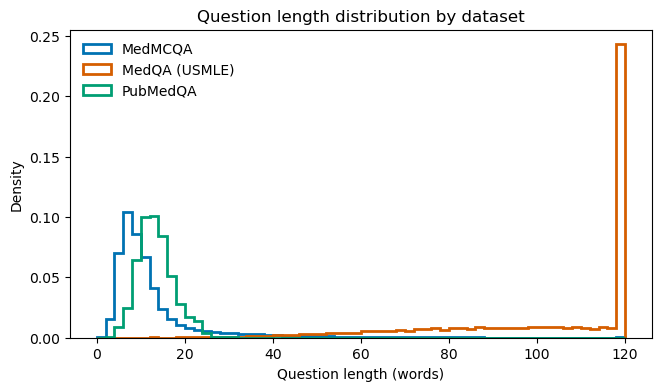

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
import numpy as np
bins = np.linspace(0, 120, 61)
for s in ["medmcqa","medqa","pubmedqa"]:
    ax.hist(df.loc[df.source==s,"q_word_len"].clip(upper=120), bins=bins, density=True,
            histtype="step", linewidth=2, color=C.PALETTE[s], label=C.PRETTY_NAME[s])
ax.set_xlabel("Question length (words)"); ax.set_ylabel("Density")
ax.set_title("Question length distribution by dataset"); ax.legend(frameon=False)
plt.show()

In [8]:
# Prompt-token budget: even the 95th percentile fits a small model's context window
df.groupby("source")["approx_prompt_tokens"].quantile([0.5, 0.95]).unstack().round(0)

,0.50,0.95
source,,
medmcqa,24.0,68.0
medqa,169.0,289.0
pubmedqa,282.0,405.0


## 5&nbsp;&nbsp;Correct-answer position balance

A systematic skew toward one option letter would let a model learn a positional
shortcut. MedQA is uniform; MedMCQA mildly favours earlier options — which we
address by shuffling option order during fine-tuning.

answer_key,A,B,C,D
source,,,,
medmcqa,29.4,26.2,23.2,21.3
medqa,25.6,25.9,25.4,23.1


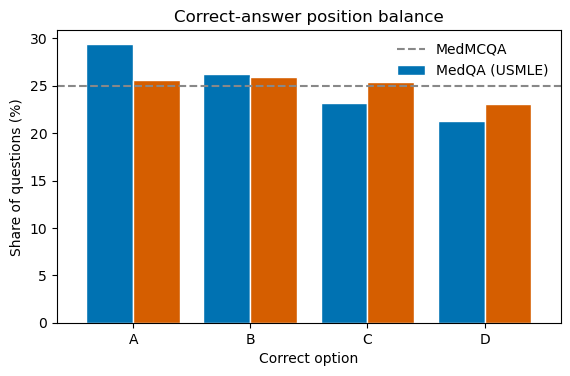

In [9]:
mcq = df[df.source.isin(["medmcqa","medqa"])]
bal = (mcq.groupby("source")["answer_key"].value_counts(normalize=True)
          .unstack()[["A","B","C","D"]].round(3) * 100)
display(bal)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
bal.T.plot(kind="bar", ax=ax, color=[C.PALETTE["medmcqa"], C.PALETTE["medqa"]],
           edgecolor="white", width=0.8)
ax.axhline(25, ls="--", color="#888"); ax.set_ylabel("Share of questions (%)")
ax.set_xlabel("Correct option"); ax.set_title("Correct-answer position balance")
ax.legend([C.PRETTY_NAME["medmcqa"], C.PRETTY_NAME["medqa"]], frameon=False)
plt.xticks(rotation=0); plt.show()

## 6&nbsp;&nbsp;Content coverage

In [10]:
# MedMCQA subject coverage (top 10) and PubMedQA class balance
display(df[df.source=="medmcqa"]["subject"].value_counts().head(10).to_frame("questions"))
display(df[df.source=="pubmedqa"]["answer_key"].value_counts().to_frame("questions"))

,questions
subject,
Medicine,18177
Surgery,17225
Pathology,15214
Anatomy,14793
Pharmacology,13993
Social & Preventive Medicine,12010
Microbiology,11434
Dental,10249
Gynaecology & Obstetrics,10237


,questions
answer_key,
yes,552
no,338
maybe,110


## 7&nbsp;&nbsp;Relationships among derived features

Word- and character-length are the same variable; question length drives the
prompt-token count; and the options-vs-context relationship is structural (MCQ
carry options but no abstract, PubMedQA the reverse). Crucially, answer position
is uncorrelated with any length variable — no length-based shortcut to the answer.

In [11]:
feats = ["q_word_len","q_char_len","opt_word_len_mean","n_options",
         "context_word_len","approx_prompt_tokens","answer_idx_num"]
corr = df[feats].corr().fillna(0).round(2)
corr.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:.2f}")

,q_word_len,q_char_len,opt_word_len_mean,n_options,context_word_len,approx_prompt_tokens,answer_idx_num
q_word_len,1.00,1.00,0.11,0.01,-0.01,0.89,0.03
q_char_len,1.00,1.00,0.11,0.01,-0.01,0.88,0.03
opt_word_len_mean,0.11,0.11,1.00,0.09,-0.09,0.29,0.04
n_options,0.01,0.01,0.09,1.00,-0.97,-0.38,0.00
context_word_len,-0.01,-0.01,-0.09,-0.97,1.00,0.39,0.00
approx_prompt_tokens,0.89,0.88,0.29,-0.38,0.39,1.00,0.04
answer_idx_num,0.03,0.03,0.04,0.00,0.00,0.04,1.00


## 8&nbsp;&nbsp;Full figure set

The polished figures below are generated by `src/eda.py` and are the ones used in
the written report.

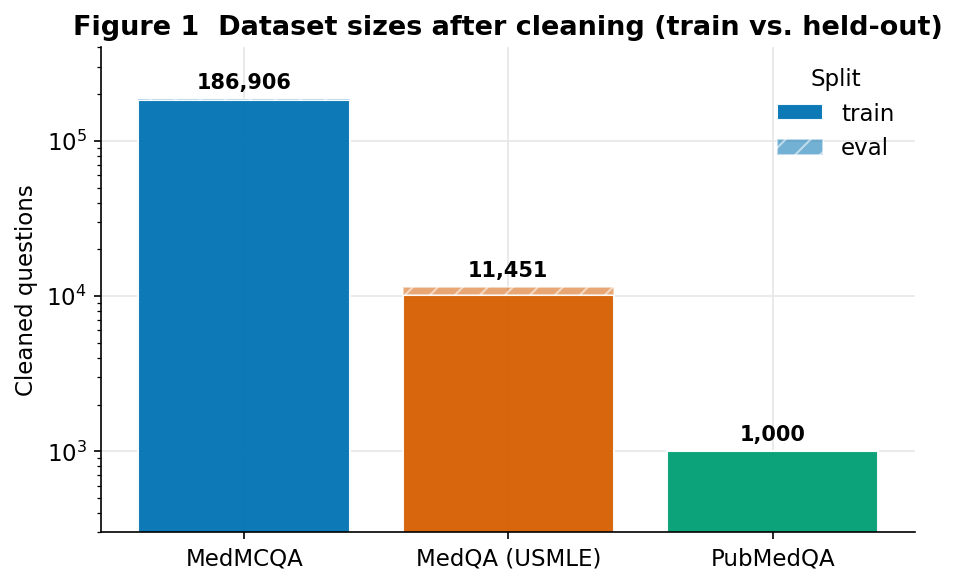

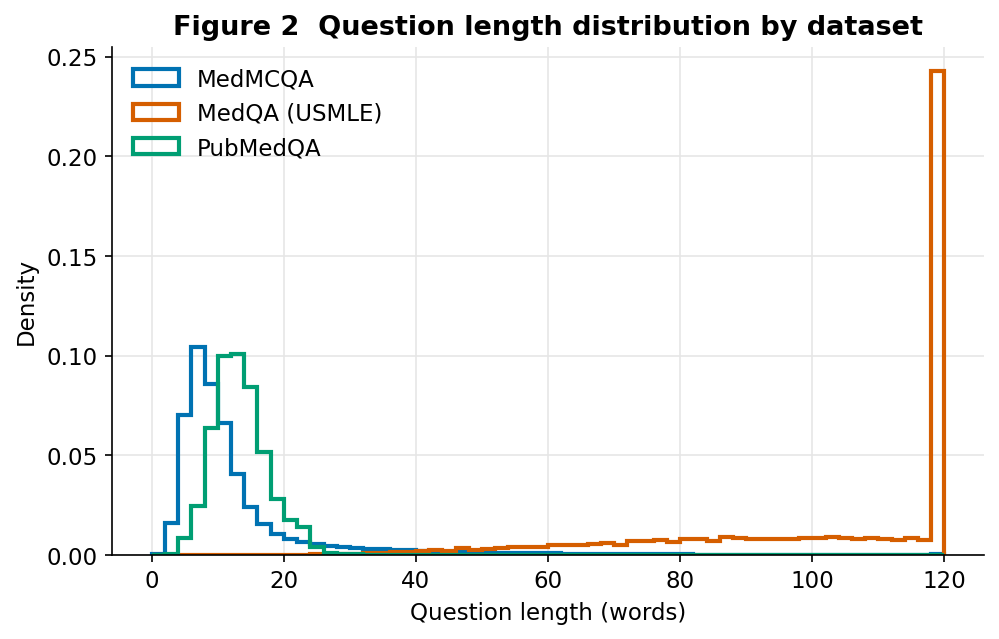

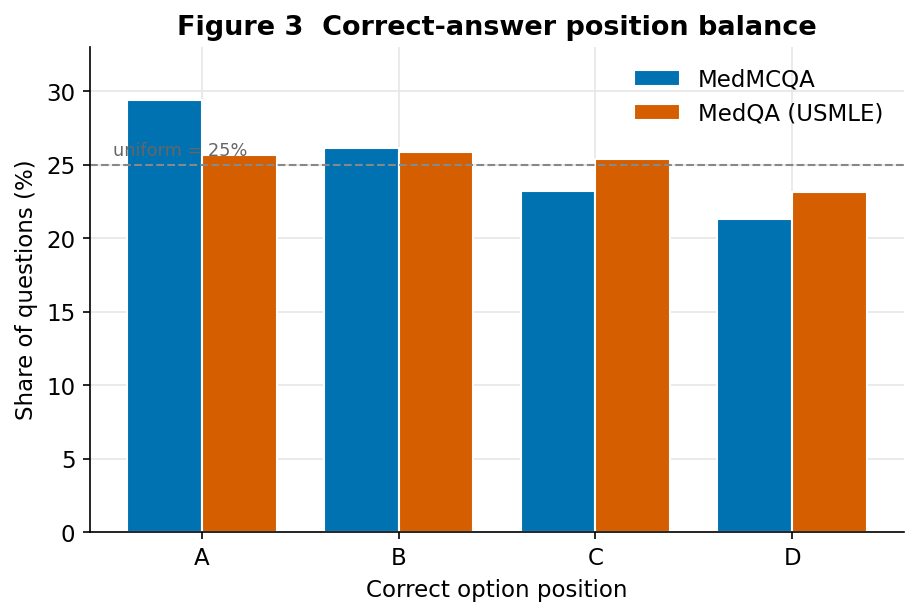

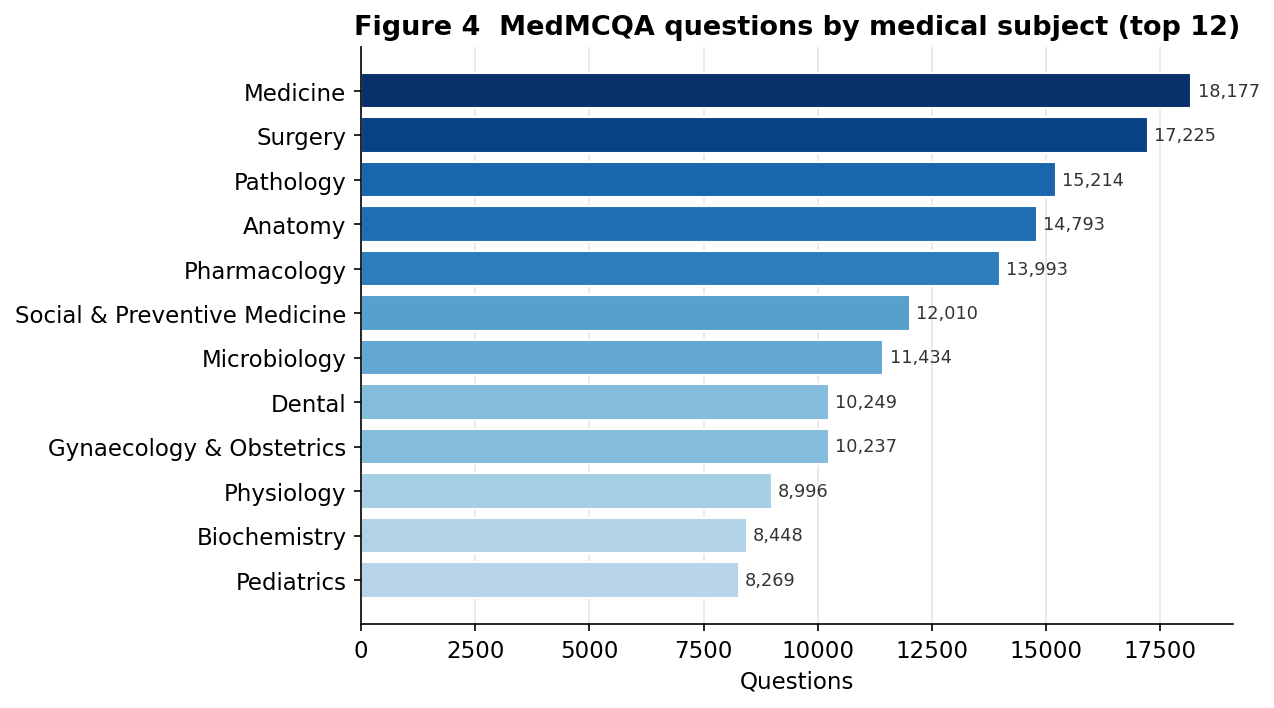

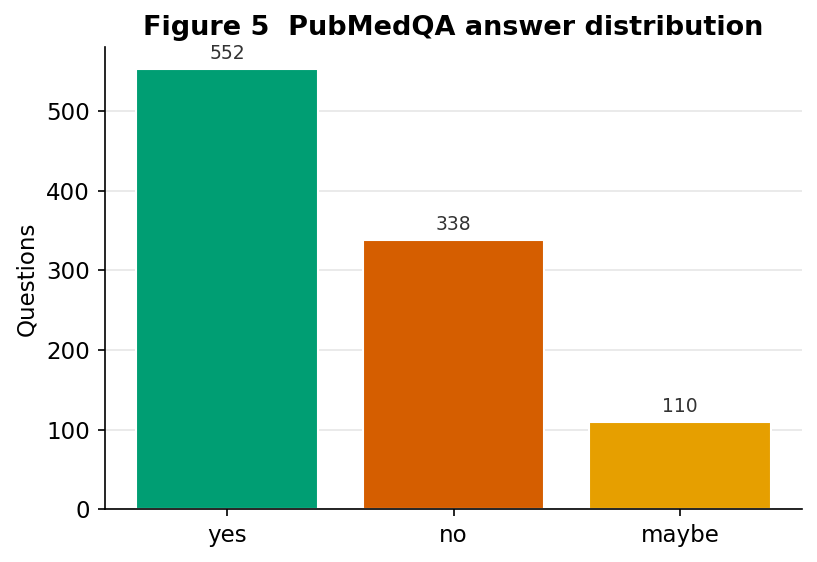

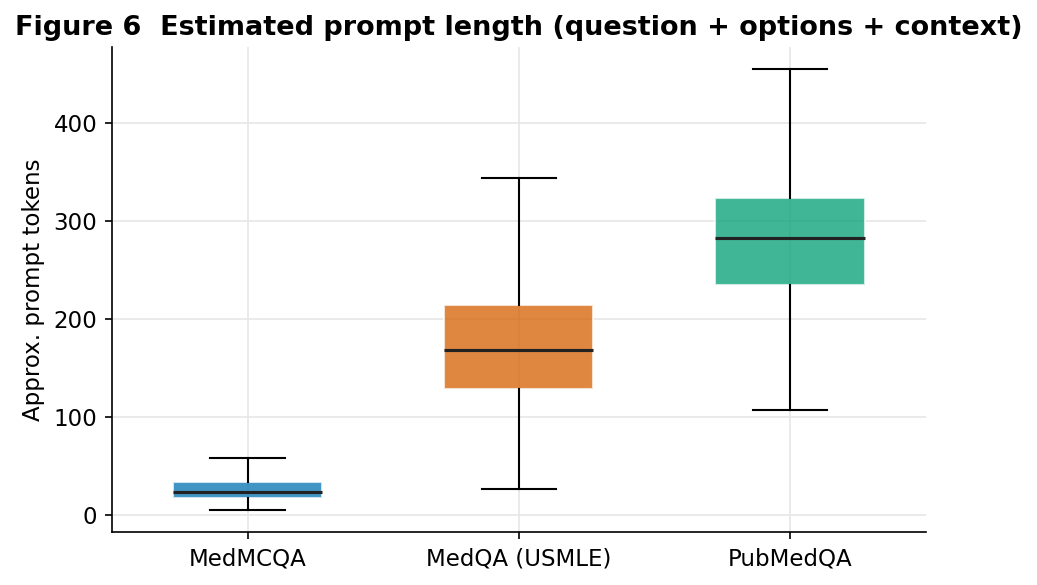

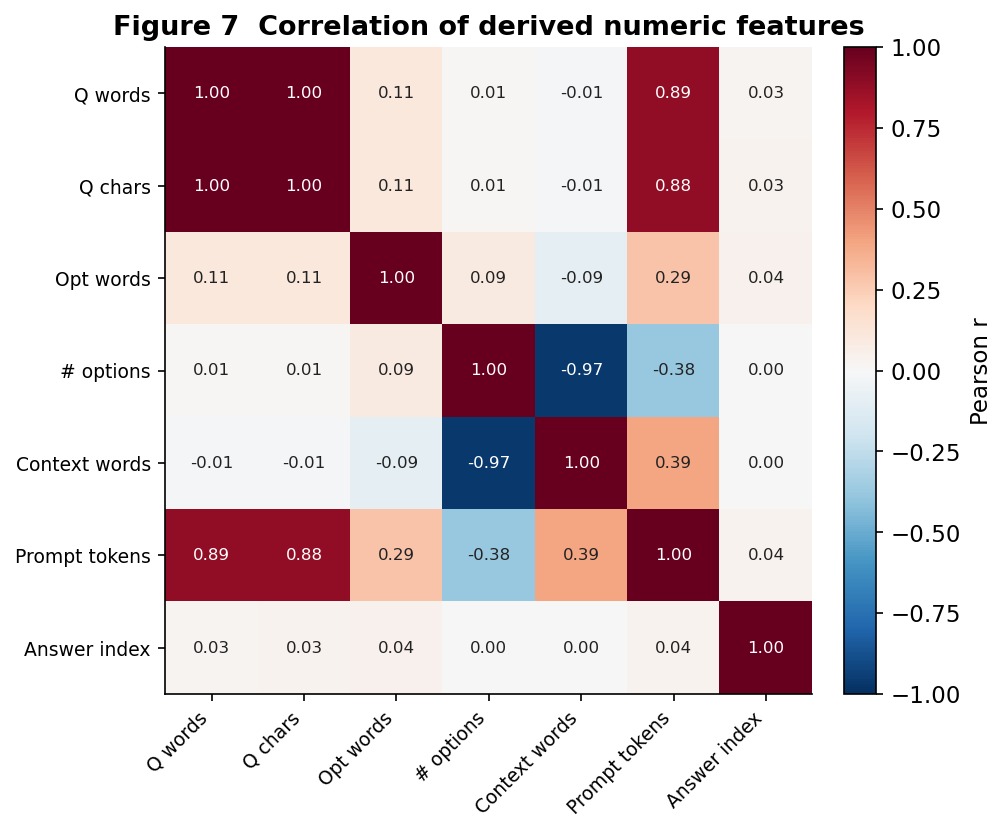

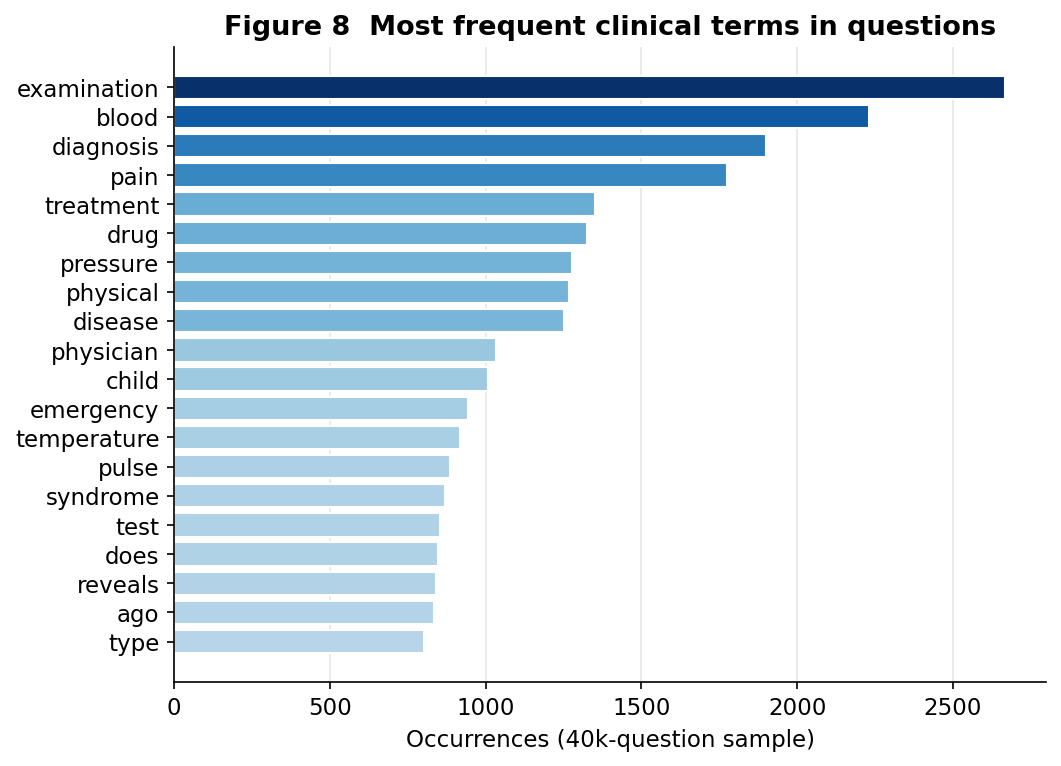

In [12]:
from IPython.display import Image, display
figs = ["fig01_dataset_sizes.png","fig02_question_length.png","fig03_answer_balance.png",
        "fig04_medmcqa_subjects.png","fig05_pubmedqa_labels.png","fig06_prompt_tokens.png",
        "fig07_correlation.png","fig08_top_terms.png"]
for f in figs:
    display(Image(filename=str(C.FIG_DIR / f)))

## Summary of findings

- The corpus is **large and broadly representative** (~199k questions across 21+
  medical subjects), dominated by MedMCQA with MedQA and PubMedQA as high-quality
  benchmarks.
- **Prompts fit a compact model's context window** (95th-percentile prompt < 500
  tokens), so we can fine-tune on complete, untruncated examples with modest compute.
- **Main quality risks are identified and addressable**: OCR-style text noise in
  MedMCQA, a mild positional answer bias (mitigated by option shuffling), and
  PubMedQA class imbalance (mitigated by weighting / stratified evaluation).
- Content is **densely clinical**, supporting a model intended to generalise
  across medicine.

*Use of AI tools:* a generative AI assistant helped scaffold and document this
notebook and the pipeline; all analysis was executed by our own code and reviewed
by the team.